# 🛡️ ClaimSense — Insurance Claim Fraud & Severity Intelligence

**End-to-end machine learning for motor-insurance claims, in one notebook.**

For every incoming claim this system answers three questions a claims manager actually asks:

1. **How likely is this claim to be fraudulent?** — classification under severe class imbalance
2. **How much will it cost us?** — regression on a heavily right-skewed target
3. **Why did the model say that?** — per-claim explanations, because "the model said so" does not survive an audit

---

### What makes this different from a typical fraud notebook

| Typical notebook | This notebook |
|---|---|
| Reports accuracy | Accuracy is banned — the base rate is ~11% |
| Uses threshold 0.5 | Threshold chosen by **expected rupees saved** |
| Ignores leakage | Leakage is structural and **asserted in code** |
| Stops at a metric | Ships a scoring function, drift monitor and API |

### Contents
1. Setup and configuration
2. Data generation (synthetic claims)
3. Data validation
4. Exploratory data analysis
5. Feature engineering
6. Train/test split
7. Fraud model — baselines vs gradient boosting
8. Threshold optimisation (the business layer)
9. Fairness slice check
10. Claim severity model
11. Explainability
12. Saving artefacts
13. Inference: scoring a live claim
14. Drift monitoring
15. Serving layer (FastAPI)
16. Results summary

## 1. Setup and configuration

Everything below is standard PyData. LightGBM / XGBoost are used **if installed**;
otherwise the notebook falls back to scikit-learn's `HistGradientBoosting`, so it
runs anywhere without a build toolchain.

In [1]:
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib
# Optional extras: lightgbm xgboost shap fastapi uvicorn

import json
import warnings
from dataclasses import dataclass
from importlib.util import find_spec
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas", pd.__version__, "| numpy", np.__version__)
for lib in ["lightgbm", "xgboost", "shap", "fastapi"]:
    print(f"{lib:<10}", "available" if find_spec(lib) else "not installed (fallback used)")

pandas 3.0.2 | numpy 2.4.4
lightgbm   not installed (fallback used)
xgboost    not installed (fallback used)
shap       not installed (fallback used)
fastapi    available


In [2]:
# ---------------------------------------------------------------- paths
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

FRAUD_MODEL_PATH = ARTIFACT_DIR / "fraud_model.joblib"
SEVERITY_MODEL_PATH = ARTIFACT_DIR / "severity_model.joblib"
METRICS_PATH = ARTIFACT_DIR / "metrics.json"

# ---------------------------------------------------------------- targets
TARGET_FRAUD = "is_fraud"
TARGET_SEVERITY = "claim_amount"
TEST_SIZE = 0.2

# ---------------------------------------------------------------- columns
CATEGORICAL_COLS = [
    "policy_state", "policy_type", "vehicle_make", "incident_type",
    "incident_severity", "authorities_contacted", "occupation", "gender",
]

NUMERIC_COLS = [
    "customer_age", "policy_tenure_months", "annual_premium", "deductible",
    "num_prior_claims", "vehicle_age", "incident_hour", "witnesses",
    "days_policy_to_incident", "police_report_filed",
    # engineered below
    "claim_to_premium_ratio", "is_night_incident", "is_weekend_incident",
    "prior_claim_rate", "young_driver_flag",
]

FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS

# ---------------------------------------------------------------- business assumptions
# These two numbers drive the operating threshold. An actuary can change them
# without retraining anything - that is the whole point of keeping them here.
COST_OF_INVESTIGATION = 250.0      # cost to manually review one flagged claim
AVG_FRAUD_LOSS_AVOIDED = 6500.0    # average loss avoided when fraud is caught

print(f"A missed fraud is {AVG_FRAUD_LOSS_AVOIDED / COST_OF_INVESTIGATION:.0f}x "
      f"more expensive than a wasted investigation.")


@dataclass
class ModelParams:
    learning_rate: float = 0.05
    max_iter: int = 400
    max_depth: int = 6
    l2_regularization: float = 1.0


FRAUD_PARAMS = ModelParams(learning_rate=0.05, max_iter=400, max_depth=6)
SEVERITY_PARAMS = ModelParams(learning_rate=0.05, max_iter=500, max_depth=8)

A missed fraud is 26x more expensive than a wasted investigation.


## 2. Data generation

This notebook ships its own **synthetic claims generator** so it runs with zero
downloads and no licensing headaches. The generating process encodes realistic
insurance signal:

**Fraud propensity rises with:** short policy tenure, prior-claim history,
night-time incidents, no police report, few witnesses, theft claims.

**Claim amount rises with:** incident severity, premium band, vehicle segment —
and includes genuine **interaction effects** (severity × vehicle age), which is
exactly why tree models will beat a linear baseline later.

> **Running on real data instead:** replace `generate()` with a loader for
> [Vehicle Insurance Claim Fraud Detection](https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection)
> or [Allstate Claims Severity](https://www.kaggle.com/c/allstate-claims-severity),
> map the columns to the names in `CATEGORICAL_COLS` / `NUMERIC_COLS`, and every
> later cell works unchanged.

In [3]:
STATES = ["MH", "KA", "DL", "TN", "GJ", "WB"]
POLICY_TYPES = ["Third Party", "Comprehensive", "Own Damage"]
MAKES = ["Maruti", "Hyundai", "Tata", "Honda", "Toyota", "Mahindra", "Kia"]
INCIDENT_TYPES = ["Collision", "Theft", "Fire", "Natural Calamity", "Vandalism"]
SEVERITIES = ["Trivial Damage", "Minor Damage", "Major Damage", "Total Loss"]
AUTHORITIES = ["Police", "Fire", "Ambulance", "Other", "None"]
OCCUPATIONS = ["Salaried", "Self-Employed", "Student", "Retired", "Professional"]


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def generate(n_rows=20_000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)

    customer_age = rng.integers(18, 75, n_rows)
    policy_tenure_months = rng.gamma(2.0, 14.0, n_rows).round().clip(0, 240)
    annual_premium = (8000 + rng.gamma(2.0, 4500, n_rows)).round(2)
    deductible = rng.choice([1000, 2500, 5000, 10000], n_rows, p=[.35, .35, .2, .1])
    num_prior_claims = rng.poisson(0.6, n_rows).clip(0, 8)
    vehicle_age = rng.integers(0, 16, n_rows)
    incident_hour = rng.integers(0, 24, n_rows)
    witnesses = rng.poisson(1.0, n_rows).clip(0, 5)
    days_policy_to_incident = (policy_tenure_months * 30 * rng.uniform(.05, 1., n_rows)).round()
    police_report_filed = rng.binomial(1, 0.65, n_rows)
    weekday = rng.integers(0, 7, n_rows)

    policy_state = rng.choice(STATES, n_rows)
    policy_type = rng.choice(POLICY_TYPES, n_rows, p=[.25, .55, .20])
    vehicle_make = rng.choice(MAKES, n_rows)
    incident_type = rng.choice(INCIDENT_TYPES, n_rows, p=[.55, .15, .08, .12, .10])
    incident_severity = rng.choice(SEVERITIES, n_rows, p=[.30, .38, .24, .08])
    authorities_contacted = rng.choice(AUTHORITIES, n_rows, p=[.45, .1, .15, .1, .2])
    occupation = rng.choice(OCCUPATIONS, n_rows)
    gender = rng.choice(["M", "F"], n_rows, p=[.62, .38])

    severity_rank = pd.Series(incident_severity).map(
        {"Trivial Damage": 0, "Minor Damage": 1, "Major Damage": 2, "Total Loss": 3}
    ).to_numpy()

    # ---- fraud propensity -------------------------------------------------
    logit = (
        -3.4
        + 1.60 * (policy_tenure_months < 6)
        + 0.62 * num_prior_claims
        + 0.95 * ((incident_hour < 5) | (incident_hour > 22))
        + 1.10 * (police_report_filed == 0)
        - 0.45 * witnesses
        + 0.55 * (incident_type == "Theft")
        + 0.35 * (policy_type == "Comprehensive")
        + 0.25 * (severity_rank == 3)
        - 0.015 * (customer_age - 40)
        + rng.normal(0, 0.25, n_rows)
    )
    is_fraud = rng.binomial(1, sigmoid(logit))

    # ---- claim amount -----------------------------------------------------
    # Non-linear + interaction effects so tree models have a real edge over a
    # plain linear baseline.
    make_value = pd.Series(vehicle_make).map(
        {"Maruti": .0, "Tata": .05, "Hyundai": .10, "Honda": .22,
         "Kia": .25, "Mahindra": .30, "Toyota": .40}
    ).to_numpy()

    base = (
        9.0
        + 0.75 * severity_rank
        + 0.000012 * annual_premium
        - 0.05 * vehicle_age
        + 0.06 * severity_rank * np.maximum(10 - vehicle_age, 0)   # interaction
        + 0.90 * make_value * (severity_rank >= 2)                 # interaction
        + 0.30 * np.sin(customer_age / 9.0)                        # non-linear
        + 0.35 * is_fraud                                          # inflated claims
        + rng.normal(0, 0.28, n_rows)
    )
    claim_amount = np.expm1(base).round(2).clip(1500, None)

    df = pd.DataFrame({
        "claim_id": [f"CLM{100000 + i}" for i in range(n_rows)],
        "customer_age": customer_age, "gender": gender, "occupation": occupation,
        "policy_state": policy_state, "policy_type": policy_type,
        "policy_tenure_months": policy_tenure_months.astype(int),
        "annual_premium": annual_premium, "deductible": deductible,
        "num_prior_claims": num_prior_claims, "vehicle_make": vehicle_make,
        "vehicle_age": vehicle_age, "incident_type": incident_type,
        "incident_severity": incident_severity, "incident_hour": incident_hour,
        "incident_weekday": weekday, "authorities_contacted": authorities_contacted,
        "witnesses": witnesses, "police_report_filed": police_report_filed,
        "days_policy_to_incident": days_policy_to_incident.astype(int),
        "claim_amount": claim_amount, "is_fraud": is_fraud,
    })

    # Realistic messiness: inject missing values.
    for col, frac in [("authorities_contacted", .06), ("witnesses", .03), ("occupation", .02)]:
        df.loc[rng.random(n_rows) < frac, col] = np.nan

    return df


raw = generate(20_000)
print(f"{len(raw):,} claims | fraud rate {raw[TARGET_FRAUD].mean():.2%} | "
      f"median claim {raw[TARGET_SEVERITY].median():,.0f}")
raw.head()

20,000 claims | fraud rate 11.19% | median claim 18,334


,claim_id,customer_age,gender,occupation,policy_state,policy_type,policy_tenure_months,annual_premium,deductible,num_prior_claims,vehicle_make,vehicle_age,incident_type,incident_severity,incident_hour,incident_weekday,authorities_contacted,witnesses,police_report_filed,days_policy_to_incident,claim_amount,is_fraud
0,CLM100000,23,M,Salaried,GJ,Own Damage,3,"27,117.3700",2500,0,Tata,9,Fire,Major Damage,5,2,Other,2.0000,0,57,"76,173.0200",1
1,CLM100001,62,M,Salaried,WB,Own Damage,52,"10,728.2200",10000,1,Maruti,14,Collision,Trivial Damage,17,3,Police,1.0000,1,1263,"5,200.1000",0
2,CLM100002,55,M,Retired,GJ,Comprehensive,34,"18,129.7400",1000,0,Tata,1,Natural Calamity,Minor Damage,15,5,Police,0.0000,1,878,"30,245.0900",0
3,CLM100003,43,M,Self-Employed,WB,Third Party,28,"23,137.5900",10000,1,Mahindra,12,Collision,Major Damage,12,6,Ambulance,1.0000,0,521,"17,667.6700",0
4,CLM100004,42,M,Retired,WB,Comprehensive,36,"17,771.5400",1000,1,Mahindra,13,Collision,Major Damage,12,6,NaN,4.0000,1,430,"22,475.6000",0


## 3. Data validation

A quality gate that runs **before** any training. In production this is the cell
that stops a broken upstream feed from silently corrupting a model.

In [4]:
REQUIRED_COLUMNS = [
    "claim_id", "customer_age", "policy_tenure_months", "annual_premium",
    "incident_type", "incident_severity", "claim_amount", "is_fraud",
]

RANGES = {
    "customer_age": (16, 100),
    "policy_tenure_months": (0, 600),
    "annual_premium": (0, 1_000_000),
    "incident_hour": (0, 23),
    "claim_amount": (0, 10_000_000),
}


class DataValidationError(ValueError):
    pass


def validate(df):
    problems = []

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise DataValidationError(f"Missing required columns: {missing}")

    if df["claim_id"].duplicated().any():
        problems.append("duplicate claim_id values found")

    for col, (lo, hi) in RANGES.items():
        if col in df.columns:
            bad = df[col].dropna()
            bad = bad[(bad < lo) | (bad > hi)]
            if len(bad):
                problems.append(f"{col}: {len(bad)} values outside [{lo}, {hi}]")

    if not set(df[TARGET_FRAUD].dropna().unique()).issubset({0, 1}):
        raise DataValidationError("is_fraud must be binary 0/1")

    return {
        "rows": int(len(df)),
        "columns": int(df.shape[1]),
        "fraud_rate": float(df[TARGET_FRAUD].mean()),
        "null_fraction": {c: round(float(df[c].isna().mean()), 4)
                          for c in df.columns if df[c].isna().any()},
        "problems": problems,
    }


quality = validate(raw)
print(json.dumps(quality, indent=2))

# Prove the gate actually bites.
try:
    validate(raw.drop(columns=["claim_amount"]))
except DataValidationError as exc:
    print("\nGate works ->", exc)

{
  "rows": 20000,
  "columns": 22,
  "fraud_rate": 0.1119,
  "null_fraction": {
    "occupation": 0.0182,
    "authorities_contacted": 0.0623,
    "witnesses": 0.0323
  },
  "problems": []
}

Gate works -> Missing required columns: ['claim_amount']


## 4. Exploratory data analysis

Four questions, four answers that shape every modelling decision that follows.

fraud rate ................ 11.19%
accuracy of a do-nothing model .. 88.81%  <- this is why accuracy is banned


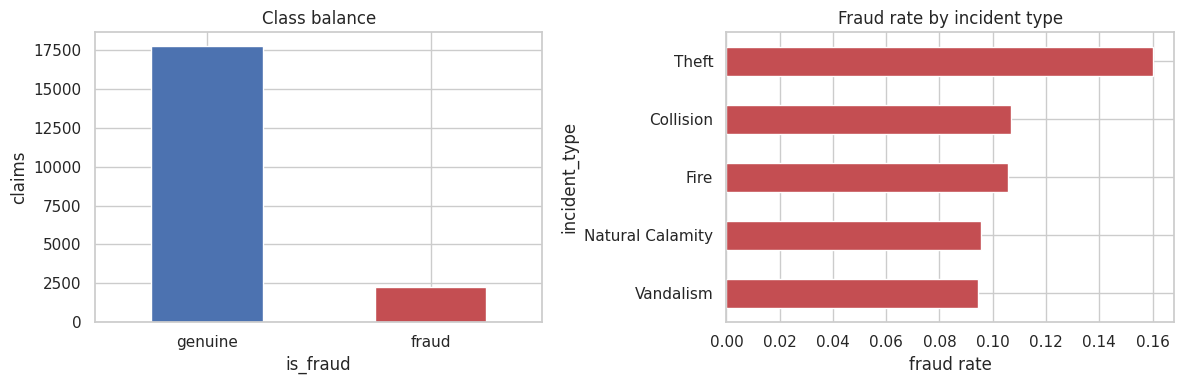

In [5]:
# ---- Q1: how imbalanced is the target? --------------------------------------
rate = raw[TARGET_FRAUD].mean()
print(f"fraud rate ................ {rate:.2%}")
print(f"accuracy of a do-nothing model .. {1 - rate:.2%}  <- this is why accuracy is banned")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw[TARGET_FRAUD].value_counts().plot(kind="bar", color=["#4c72b0", "#c44e52"], ax=axes[0])
axes[0].set_xticklabels(["genuine", "fraud"], rotation=0)
axes[0].set_title("Class balance")
axes[0].set_ylabel("claims")

raw.groupby("incident_type")[TARGET_FRAUD].mean().sort_values().plot(
    kind="barh", color="#c44e52", ax=axes[1])
axes[1].set_title("Fraud rate by incident type")
axes[1].set_xlabel("fraud rate")
plt.tight_layout()
plt.show()

In [6]:
# ---- Q2: which raw signals separate fraud? ----------------------------------
for col in ["incident_severity", "policy_type", "authorities_contacted"]:
    summary = (raw.groupby(col)[TARGET_FRAUD]
               .agg(fraud_rate="mean", n="size")
               .sort_values("fraud_rate", ascending=False))
    print(f"\n--- {col} ---")
    print(summary.round(3).to_string())


--- incident_severity ---
                   fraud_rate     n
incident_severity                  
Total Loss             0.1370  1538
Trivial Damage         0.1170  5991
Major Damage           0.1070  4816
Minor Damage           0.1060  7655

--- policy_type ---
               fraud_rate      n
policy_type                     
Comprehensive      0.1250  11021
Third Party        0.0970   5010
Own Damage         0.0950   3969

--- authorities_contacted ---
                       fraud_rate     n
authorities_contacted                  
Other                      0.1200  1838
Police                     0.1150  8500
Fire                       0.1100  1841
None                       0.1100  3730
Ambulance                  0.1010  2845


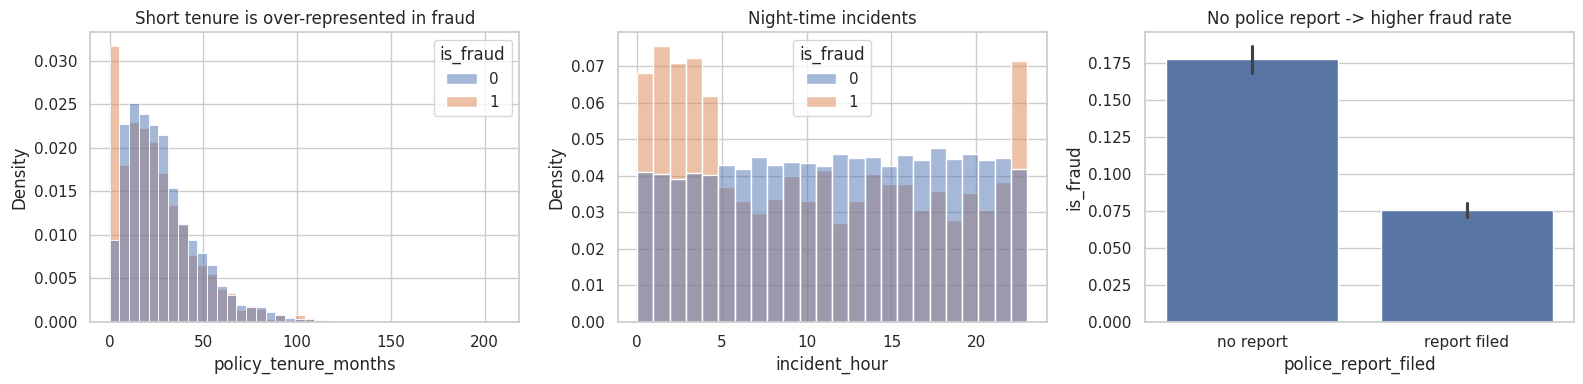

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=raw, x="policy_tenure_months", hue=TARGET_FRAUD, bins=40,
             stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Short tenure is over-represented in fraud")

sns.histplot(data=raw, x="incident_hour", hue=TARGET_FRAUD, bins=24,
             stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Night-time incidents")

sns.barplot(data=raw, x="police_report_filed", y=TARGET_FRAUD, ax=axes[2])
axes[2].set_title("No police report -> higher fraud rate")
axes[2].set_xticklabels(["no report", "report filed"])
plt.tight_layout()
plt.show()

skew raw  : 6.45
skew log1p: 0.68


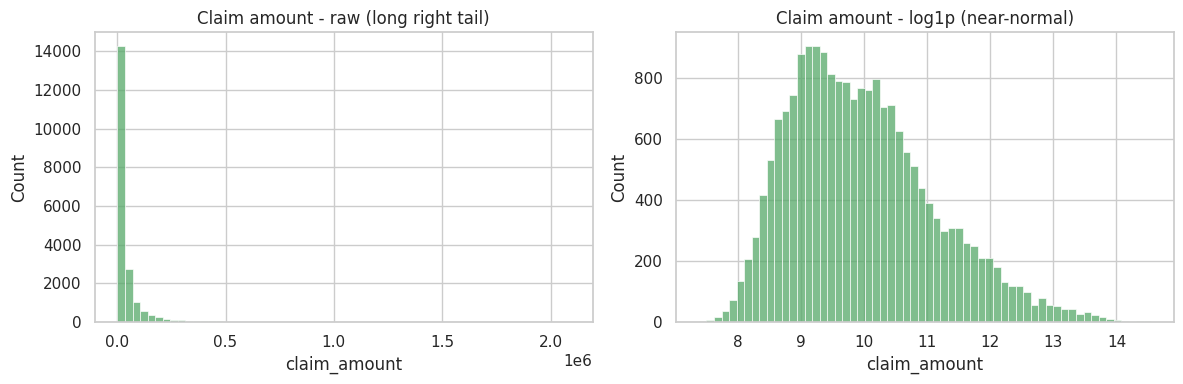


Decision: train the severity model on log1p(claim_amount), invert with expm1 at prediction time.


In [8]:
# ---- Q3: how skewed is the claim amount? ------------------------------------
print("skew raw  :", round(raw[TARGET_SEVERITY].skew(), 2))
print("skew log1p:", round(np.log1p(raw[TARGET_SEVERITY]).skew(), 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw[TARGET_SEVERITY], bins=60, ax=axes[0], color="#55a868")
axes[0].set_title("Claim amount - raw (long right tail)")
sns.histplot(np.log1p(raw[TARGET_SEVERITY]), bins=60, ax=axes[1], color="#55a868")
axes[1].set_title("Claim amount - log1p (near-normal)")
plt.tight_layout()
plt.show()

print("\nDecision: train the severity model on log1p(claim_amount), "
      "invert with expm1 at prediction time.")

## 5. Feature engineering

Six domain features, none of which touch the fraud label. Each one encodes a
pattern a claims investigator would recognise.

| Feature | Definition | Why it matters |
|---|---|---|
| `claim_to_premium_ratio` | claim ÷ annual premium | exposure-normalised claim size — a small policy with a huge claim is the classic pattern |
| `is_night_incident` | 23:00–05:00 | fewer witnesses, harder to verify |
| `is_weekend_incident` | Sat/Sun | different accident mix and reporting behaviour |
| `prior_claim_rate` | prior claims ÷ policy years | frequency beats raw count — fair to new policies |
| `young_driver_flag` | age < 25 | distinct risk and cost profile |
| `days_policy_to_incident` | inception → loss | very early losses are a known red flag |

### ⚠️ The leakage rule

`claim_to_premium_ratio` is derived from `claim_amount` — which is the **target** of
the severity model. It is my strongest fraud feature and a fatal leak for severity.
So feature selection is **task-aware**, and the notebook asserts it rather than
trusting me to remember.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def add_domain_features(df):
    out = df.copy()

    out["witnesses"] = out["witnesses"].fillna(0)
    out["authorities_contacted"] = out["authorities_contacted"].fillna("Unknown")
    out["occupation"] = out["occupation"].fillna("Unknown")

    out["claim_to_premium_ratio"] = (
        out.get(TARGET_SEVERITY, pd.Series(np.nan, index=out.index)) / out["annual_premium"]
    )
    out["is_night_incident"] = ((out["incident_hour"] < 5) | (out["incident_hour"] > 22)).astype(int)
    out["is_weekend_incident"] = out.get(
        "incident_weekday", pd.Series(0, index=out.index)).isin([5, 6]).astype(int)
    out["prior_claim_rate"] = out["num_prior_claims"] / (out["policy_tenure_months"] / 12 + 1)
    out["young_driver_flag"] = (out["customer_age"] < 25).astype(int)

    return out


def numeric_cols_for(task):
    # The severity target IS claim_amount, so every feature derived from it goes.
    cols = list(NUMERIC_COLS)
    return [c for c in cols if c != "claim_to_premium_ratio"] if task == "severity" else cols


def feature_frame(df, task):
    cols = CATEGORICAL_COLS + numeric_cols_for(task)
    return df[cols]


def build_preprocessor(task):
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ])
    return ColumnTransformer(
        [("num", numeric_pipe, numeric_cols_for(task)),
         ("cat", categorical_pipe, CATEGORICAL_COLS)],
        remainder="drop", verbose_feature_names_out=False,
    )


featured = add_domain_features(raw)

# --- leakage assertions: these would fail the build in a real repo -----------
assert "claim_to_premium_ratio" in feature_frame(featured, "fraud").columns
assert "claim_to_premium_ratio" not in feature_frame(featured, "severity").columns
assert TARGET_FRAUD not in feature_frame(featured, "fraud").columns
assert TARGET_SEVERITY not in feature_frame(featured, "severity").columns
print("Leakage checks passed.")

featured.groupby(TARGET_FRAUD)[
    ["claim_to_premium_ratio", "is_night_incident", "is_weekend_incident",
     "prior_claim_rate", "young_driver_flag"]
].mean().T.round(3)

Leakage checks passed.


is_fraud,0,1
claim_to_premium_ratio,2.8690,4.5180
is_night_incident,0.2330,0.4030
is_weekend_incident,0.2850,0.2760
prior_claim_rate,0.2020,0.3700
young_driver_flag,0.1190,0.1590


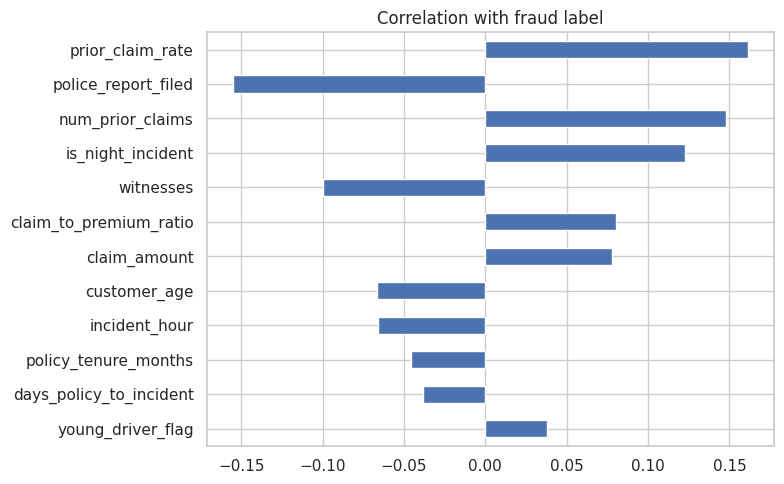

prior_claim_rate          0.1620
police_report_filed      -0.1550
num_prior_claims          0.1480
is_night_incident         0.1230
witnesses                -0.1000
claim_to_premium_ratio    0.0810
claim_amount              0.0780
customer_age             -0.0660
dtype: float64

In [10]:
# Correlation of every numeric feature with the fraud label.
num = featured.select_dtypes("number").drop(columns=[TARGET_FRAUD])
corr = num.corrwith(featured[TARGET_FRAUD]).sort_values(key=abs, ascending=False)

corr.head(12).plot(kind="barh", color="#4c72b0", figsize=(8, 5))
plt.title("Correlation with fraud label")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
corr.head(8).round(3)

## 6. Train/test split

Stratified on the fraud label so both sides keep the same 11% base rate.

> On real claims data you would use a **time-based split** instead — fraud
> patterns evolve, and a random split leaks the future into the past.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

train, test = train_test_split(
    featured, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=featured[TARGET_FRAUD],
)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"train {len(train):,} rows | fraud rate {train[TARGET_FRAUD].mean():.2%}")
print(f"test  {len(test):,} rows | fraud rate {test[TARGET_FRAUD].mean():.2%}")

train 16,000 rows | fraud rate 11.19%
test  4,000 rows | fraud rate 11.20%


## 7. Fraud model — baselines before anything clever

Three models, same pipeline, honest comparison:

1. **Majority class** — the floor any model must beat
2. **Logistic regression** (class-weighted) — the interpretable benchmark
3. **Gradient-boosted trees** — the candidate

Imbalance is handled with **class weighting**, not blind SMOTE, so predicted
probabilities stay interpretable (I report Brier score to check calibration).

In [12]:
def make_classifier(params, scale_pos_weight=1.0):
    if find_spec("lightgbm"):
        from lightgbm import LGBMClassifier
        return LGBMClassifier(
            learning_rate=params.learning_rate, n_estimators=params.max_iter,
            max_depth=params.max_depth, reg_lambda=params.l2_regularization,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, verbose=-1)
    if find_spec("xgboost"):
        from xgboost import XGBClassifier
        return XGBClassifier(
            learning_rate=params.learning_rate, n_estimators=params.max_iter,
            max_depth=params.max_depth, reg_lambda=params.l2_regularization,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            eval_metric="aucpr", tree_method="hist")
    from sklearn.ensemble import HistGradientBoostingClassifier
    return HistGradientBoostingClassifier(
        learning_rate=params.learning_rate, max_iter=params.max_iter,
        max_depth=params.max_depth, l2_regularization=params.l2_regularization,
        class_weight="balanced", random_state=RANDOM_STATE)


def make_regressor(params):
    if find_spec("lightgbm"):
        from lightgbm import LGBMRegressor
        return LGBMRegressor(
            learning_rate=params.learning_rate, n_estimators=params.max_iter,
            max_depth=params.max_depth, reg_lambda=params.l2_regularization,
            random_state=RANDOM_STATE, verbose=-1)
    if find_spec("xgboost"):
        from xgboost import XGBRegressor
        return XGBRegressor(
            learning_rate=params.learning_rate, n_estimators=params.max_iter,
            max_depth=params.max_depth, reg_lambda=params.l2_regularization,
            random_state=RANDOM_STATE, tree_method="hist")
    from sklearn.ensemble import HistGradientBoostingRegressor
    return HistGradientBoostingRegressor(
        learning_rate=params.learning_rate, max_iter=params.max_iter,
        max_depth=params.max_depth, l2_regularization=params.l2_regularization,
        random_state=RANDOM_STATE)


BACKEND = ("lightgbm" if find_spec("lightgbm")
           else "xgboost" if find_spec("xgboost")
           else "sklearn-hist-gradient-boosting")
print("gradient boosting backend:", BACKEND)

gradient boosting backend: sklearn-hist-gradient-boosting


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

X_tr, y_tr = feature_frame(train, "fraud"), train[TARGET_FRAUD]
X_te, y_te = feature_frame(test, "fraud"), test[TARGET_FRAUD]

pos_weight = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
print(f"scale_pos_weight = {pos_weight:.2f}")

candidates = {
    "majority_class": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "gradient_boosting": make_classifier(FRAUD_PARAMS, pos_weight),
}

fitted, rows = {}, []
for name, estimator in candidates.items():
    pipe = Pipeline([("pre", build_preprocessor("fraud")), ("model", estimator)])
    pipe.fit(X_tr, y_tr)
    prob = pipe.predict_proba(X_te)[:, 1]
    fitted[name] = (pipe, prob)
    rows.append({
        "model": name,
        "pr_auc": average_precision_score(y_te, prob),
        "roc_auc": roc_auc_score(y_te, prob),
    })

leaderboard = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
leaderboard.round(3)

scale_pos_weight = 7.94


,model,pr_auc,roc_auc
0,gradient_boosting,0.4610,0.8310
1,logistic_regression,0.3060,0.7470
2,majority_class,0.1120,0.5000


In [14]:
# Cross-validation: is the gain real, or a lucky split?
fraud_model, fraud_prob = fitted["gradient_boosting"]

cv_scores = cross_val_score(
    Pipeline([("pre", build_preprocessor("fraud")),
              ("model", make_classifier(FRAUD_PARAMS, pos_weight))]),
    X_tr, y_tr,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring="average_precision", n_jobs=-1,
)
print(f"5-fold CV PR-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print("folds:", np.round(cv_scores, 3))

5-fold CV PR-AUC: 0.398 +/- 0.013
folds: [0.411 0.412 0.398 0.386 0.38 ]


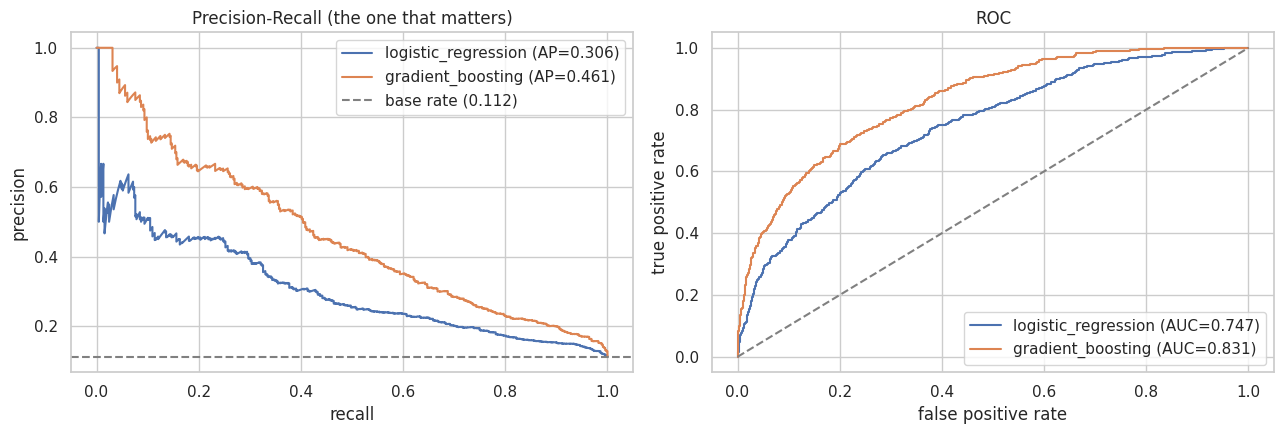

In [15]:
from sklearn.metrics import precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, (_, prob) in fitted.items():
    if name == "majority_class":
        continue
    p, r, _ = precision_recall_curve(y_te, prob)
    axes[0].plot(r, p, label=f"{name} (AP={average_precision_score(y_te, prob):.3f})")
    fpr, tpr, _ = roc_curve(y_te, prob)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te, prob):.3f})")

axes[0].axhline(y_te.mean(), ls="--", c="grey", label=f"base rate ({y_te.mean():.3f})")
axes[0].set(xlabel="recall", ylabel="precision", title="Precision-Recall (the one that matters)")
axes[0].legend()

axes[1].plot([0, 1], [0, 1], ls="--", c="grey")
axes[1].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Threshold optimisation — where the money is

A probability is not a decision. Somebody has to pick the cut-off, and `0.5`
is an arbitrary default with no business meaning.

```
net savings = (fraud caught × loss avoided) − (every flagged claim × review cost)
```

With ₹250 per investigation and ₹6,500 average loss avoided, a **missed fraud is
26× more expensive than a wasted review** — so the optimum leans hard towards
recall. That is a finance decision, not a modelling one.

In [16]:
from sklearn.metrics import brier_score_loss, confusion_matrix, f1_score


def classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "f1": float(f1_score(y_true, y_pred)),
        "precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
        "brier": float(brier_score_loss(y_true, y_prob)),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }


def expected_savings(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tp * AVG_FRAUD_LOSS_AVOIDED - (tp + fp) * COST_OF_INVESTIGATION


def optimal_threshold(y_true, y_prob, objective="cost"):
    grid = np.linspace(0.05, 0.95, 91)
    if objective == "f1":
        scores = [f1_score(y_true, (y_prob >= t).astype(int)) for t in grid]
    else:
        scores = [expected_savings(y_true, y_prob, t) for t in grid]
    best = int(np.argmax(scores))
    return float(grid[best]), float(scores[best]), grid, np.array(scores)


thr_cost, savings, grid, savings_curve = optimal_threshold(y_te, fraud_prob, "cost")
thr_f1, best_f1, _, f1_curve = optimal_threshold(y_te, fraud_prob, "f1")

comparison = pd.DataFrame([
    {"objective": "default 0.5", **classification_metrics(y_te, fraud_prob, 0.5)},
    {"objective": "maximise F1", **classification_metrics(y_te, fraud_prob, thr_f1)},
    {"objective": "maximise savings", **classification_metrics(y_te, fraud_prob, thr_cost)},
]).drop(columns=["confusion_matrix"])

print(f"cost-optimal threshold : {thr_cost:.2f}")
print(f"net savings on test set: {savings:,.0f}")
comparison[["objective", "threshold", "precision", "recall", "f1", "pr_auc", "brier"]].round(3)

cost-optimal threshold : 0.18
net savings on test set: 2,168,500


,objective,threshold,precision,recall,f1,pr_auc,brier
0,default 0.5,0.5000,0.3280,0.6290,0.4310,0.4610,0.1310
1,maximise F1,0.5900,0.4090,0.5200,0.4580,0.4610,0.1310
2,maximise savings,0.1800,0.1690,0.9640,0.2870,0.4610,0.1310


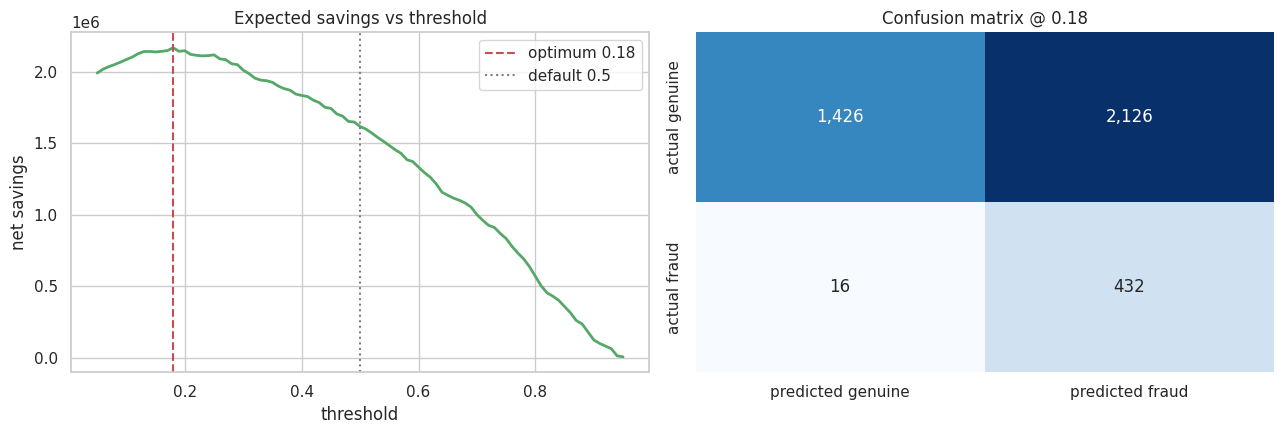

Caught 432 of 448 frauds (96.4%), at the cost of reviewing 2,126 genuine claims.
Loss avoided 2,808,000 - review cost 639,500 = 2,168,500 net


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(grid, savings_curve, color="#55a868", lw=2)
axes[0].axvline(thr_cost, ls="--", c="#c44e52", label=f"optimum {thr_cost:.2f}")
axes[0].axvline(0.5, ls=":", c="grey", label="default 0.5")
axes[0].set(xlabel="threshold", ylabel="net savings", title="Expected savings vs threshold")
axes[0].legend()

cm = confusion_matrix(y_te, (fraud_prob >= thr_cost).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["predicted genuine", "predicted fraud"],
            yticklabels=["actual genuine", "actual fraud"])
axes[1].set_title(f"Confusion matrix @ {thr_cost:.2f}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Caught {tp} of {tp + fn} frauds ({tp / (tp + fn):.1%}), "
      f"at the cost of reviewing {fp:,} genuine claims.")
print(f"Loss avoided {tp * AVG_FRAUD_LOSS_AVOIDED:,.0f} - "
      f"review cost {(tp + fp) * COST_OF_INVESTIGATION:,.0f} = {savings:,.0f} net")

## 9. Fairness slice check

The first question any insurance regulator asks: *does this model treat groups
differently?* Reported as part of training output — not assembled after someone
complains.

In [18]:
def fairness_slices(df, y_true, y_prob, slice_cols, threshold):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    out = {}
    for col in slice_cols:
        rows = {}
        for value in df[col].dropna().unique():
            mask = (df[col] == value).to_numpy()
            if mask.sum() < 50:
                continue
            rows[str(value)] = {
                "n": int(mask.sum()),
                "flag_rate": float(y_pred[mask].mean()),
                "recall": float(y_pred[mask & (y_true == 1)].mean())
                if (mask & (y_true == 1)).any() else None,
            }
        out[col] = rows
    return out


fairness = fairness_slices(test, y_te, fraud_prob, ["gender", "policy_state"], thr_cost)

gender_df = pd.DataFrame(fairness["gender"]).T
print("By gender:")
print(gender_df.round(3).to_string())
gap = gender_df["flag_rate"].max() - gender_df["flag_rate"].min()
print(f"\nFlag-rate gap: {gap:.3f} -> " + ("acceptable" if gap < 0.05 else "INVESTIGATE"))

print("\nBy state:")
print(pd.DataFrame(fairness["policy_state"]).T.round(3).to_string())

By gender:
           n  flag_rate  recall
M 2,474.0000     0.6410  0.9570
F 1,526.0000     0.6380  0.9770

Flag-rate gap: 0.003 -> acceptable

By state:
          n  flag_rate  recall
KA 656.0000     0.6430  0.9750
MH 664.0000     0.6600  0.9540
WB 638.0000     0.6070  0.9550
GJ 657.0000     0.6510  0.9840
DL 666.0000     0.6520  0.9870
TN 719.0000     0.6240  0.9320


## 10. Claim severity model

Same pipeline, different question: **how much will this claim cost?**

Two decisions worth defending:
- **Log target.** Claim amounts are heavily right-skewed; a handful of total-loss
  claims would dominate squared error. Train on `log1p`, invert with `expm1`.
- **Ridge baseline first.** If a linear model matched the trees, I'd ship the
  linear model. It doesn't — because repair cost depends on severity *and*
  vehicle age *together*, an interaction a linear model cannot express.

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

Xs_tr = feature_frame(train, "severity")
Xs_te = feature_frame(test, "severity")
ys_tr = np.log1p(train[TARGET_SEVERITY])      # <- log target
ys_te_raw = test[TARGET_SEVERITY]


def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "rmsle": float(np.sqrt(np.mean(
            (np.log1p(np.clip(y_pred, 0, None)) - np.log1p(y_true)) ** 2))),
        "r2": float(r2_score(y_true, y_pred)),
        "mape": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    }


severity_candidates = {
    "ridge_regression": Ridge(alpha=1.0),
    "gradient_boosting": make_regressor(SEVERITY_PARAMS),
}

severity_rows, severity_fitted = [], {}
for name, estimator in severity_candidates.items():
    pipe = Pipeline([("pre", build_preprocessor("severity")), ("model", estimator)])
    pipe.fit(Xs_tr, ys_tr)
    pred = np.expm1(pipe.predict(Xs_te))       # <- invert the log transform
    severity_fitted[name] = (pipe, pred)
    severity_rows.append({"model": name, **regression_metrics(ys_te_raw, pred)})

severity_board = pd.DataFrame(severity_rows).sort_values("mae").reset_index(drop=True)
severity_board.round(3)

,model,mae,rmse,rmsle,r2,mape
0,gradient_boosting,"11,820.2670","38,455.0580",0.3020,0.8570,24.6880
1,ridge_regression,"17,639.0020","63,080.8700",0.3960,0.6160,32.8450


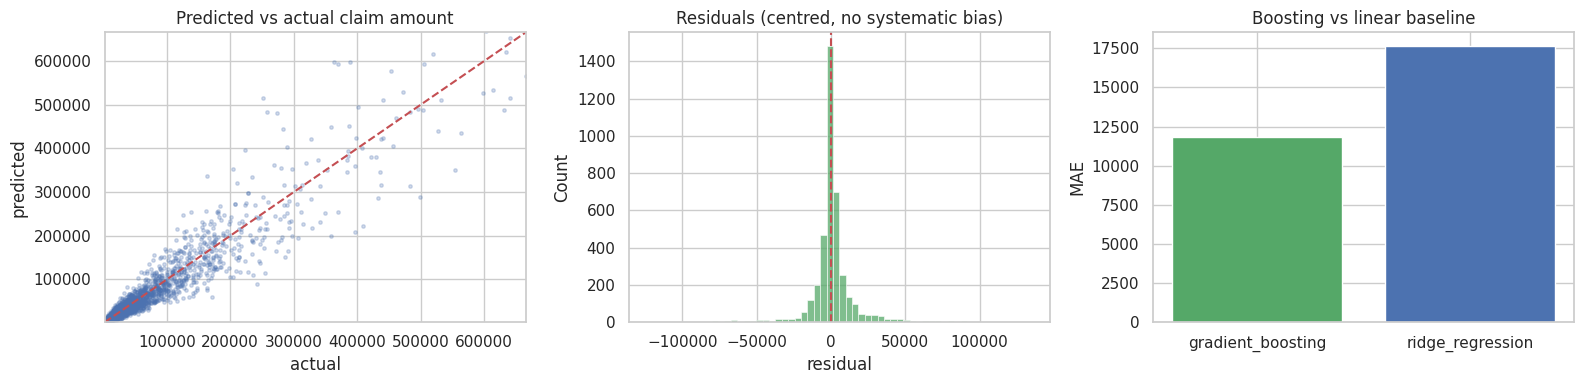

Best model cuts MAE by 33.0% versus the weaker baseline.


In [20]:
severity_model, severity_pred = severity_fitted["gradient_boosting"]
residuals = ys_te_raw - severity_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ys_te_raw, severity_pred, s=6, alpha=.25, color="#4c72b0")
lims = [ys_te_raw.min(), ys_te_raw.quantile(0.995)]
axes[0].plot(lims, lims, "--", c="#c44e52")
axes[0].set(xlim=lims, ylim=lims, xlabel="actual", ylabel="predicted",
            title="Predicted vs actual claim amount")

sns.histplot(residuals[residuals.abs() < residuals.abs().quantile(.99)],
             bins=60, ax=axes[1], color="#55a868")
axes[1].axvline(0, ls="--", c="#c44e52")
axes[1].set(xlabel="residual", title="Residuals (centred, no systematic bias)")

axes[2].bar(severity_board["model"], severity_board["mae"], color=["#55a868", "#4c72b0"])
axes[2].set(ylabel="MAE", title="Boosting vs linear baseline")
plt.tight_layout()
plt.show()

improvement = (severity_board.iloc[-1]["mae"] - severity_board.iloc[0]["mae"]) / severity_board.iloc[-1]["mae"]
print(f"Best model cuts MAE by {improvement:.1%} versus the weaker baseline.")

## 11. Explainability

An insurer cannot decline a claim because "the model said 0.87". Every flagged
claim needs signed drivers: what pushed risk **up**, what pushed it **down**.

Uses **SHAP** when installed; otherwise falls back to permutation importance
(global) and occlusion (per-claim), so this section always produces output.

explanation method: permutation


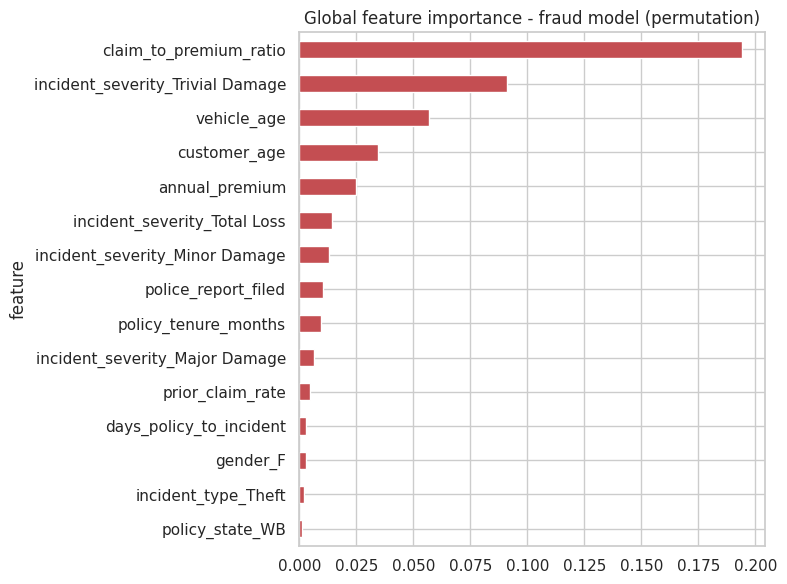

In [21]:
def feature_names(pipeline):
    return list(pipeline.named_steps["pre"].get_feature_names_out())


def transform(pipeline, X):
    Xt = pipeline.named_steps["pre"].transform(X)
    return Xt.toarray() if hasattr(Xt, "toarray") else Xt


def global_importance(pipeline, X, y=None, top_n=15):
    names = feature_names(pipeline)
    Xt = transform(pipeline, X.head(2000))
    try:
        import shap
        explainer = shap.Explainer(pipeline.named_steps["model"], Xt)
        values = explainer(Xt).values
        if values.ndim == 3:
            values = values[..., -1]
        score, method = np.abs(values).mean(axis=0), "shap"
    except Exception:
        from sklearn.inspection import permutation_importance
        r = permutation_importance(pipeline.named_steps["model"], Xt, y.head(2000),
                                   n_repeats=5, random_state=RANDOM_STATE)
        score, method = r.importances_mean, "permutation"
    out = pd.DataFrame({"feature": names, "importance": score})
    return out.sort_values("importance", ascending=False).head(top_n).reset_index(drop=True), method


importance, method = global_importance(fraud_model, X_te, y_te)
print("explanation method:", method)

importance.set_index("feature")["importance"].plot(
    kind="barh", figsize=(8, 6), color="#c44e52")
plt.gca().invert_yaxis()
plt.title(f"Global feature importance - fraud model ({method})")
plt.tight_layout()
plt.show()

In [22]:
def explain_claim(pipeline, row, top_n=6):
    names = feature_names(pipeline)
    Xt = transform(pipeline, row)
    try:
        import shap
        explainer = shap.Explainer(pipeline.named_steps["model"], Xt)
        vals = explainer(Xt).values
        if vals.ndim == 3:
            vals = vals[..., -1]
        contrib = vals[0]
    except Exception:
        # Occlusion fallback: neutralise one feature at a time, measure the move.
        model = pipeline.named_steps["model"]
        predict_fn = model.predict_proba if hasattr(model, "predict_proba") else model.predict
        base = predict_fn(Xt)
        base = base[0, -1] if getattr(base, "ndim", 1) > 1 else base[0]
        contrib = np.zeros(Xt.shape[1])
        for j in range(Xt.shape[1]):
            perturbed = Xt.copy()
            perturbed[0, j] = 0.0
            p = predict_fn(perturbed)
            p = p[0, -1] if getattr(p, "ndim", 1) > 1 else p[0]
            contrib[j] = base - p

    order = np.argsort(np.abs(contrib))[::-1][:top_n]
    return pd.DataFrame([{
        "feature": names[i],
        "contribution": round(float(contrib[i]), 4),
        "direction": "increases risk" if contrib[i] > 0 else "decreases risk",
    } for i in order])


# Explain the single riskiest claim in the test set.
riskiest = int(np.argmax(fraud_prob))
print(f"claim {test.loc[riskiest, 'claim_id']} | fraud probability {fraud_prob[riskiest]:.3f}")
explain_claim(fraud_model, feature_frame(test.iloc[[riskiest]], "fraud"))

claim CLM113851 | fraud probability 0.951


,feature,contribution,direction
0,vehicle_age,0.1088,increases risk
1,claim_to_premium_ratio,0.0636,increases risk
2,police_report_filed,0.0571,increases risk
3,policy_tenure_months,0.0507,increases risk
4,incident_severity_Total Loss,-0.0194,decreases risk
5,is_night_incident,0.0184,increases risk


## 12. Saving artefacts

The model, the chosen threshold and the full metrics report are persisted
together. Shipping the threshold **with** the model matters — a pipeline without
its operating point is only half a decision system.

In [23]:
joblib.dump({"pipeline": fraud_model, "threshold": thr_cost, "task": "fraud"},
            FRAUD_MODEL_PATH)
joblib.dump({"pipeline": severity_model, "log_target": True, "task": "severity"},
            SEVERITY_MODEL_PATH)

metrics = {
    "backend": BACKEND,
    "data_quality": quality,
    "fraud": {
        "leaderboard": leaderboard.to_dict("records"),
        "cv_pr_auc_mean": float(cv_scores.mean()),
        "cv_pr_auc_std": float(cv_scores.std()),
        "at_default_threshold": classification_metrics(y_te, fraud_prob, 0.5),
        "at_f1_threshold": classification_metrics(y_te, fraud_prob, thr_f1),
        "at_cost_threshold": classification_metrics(y_te, fraud_prob, thr_cost),
        "chosen_threshold": thr_cost,
        "expected_savings": float(savings),
        "fairness": fairness,
    },
    "severity": {"leaderboard": severity_board.to_dict("records")},
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2, default=float))

for path in [FRAUD_MODEL_PATH, SEVERITY_MODEL_PATH, METRICS_PATH]:
    print(f"{path}  ({path.stat().st_size / 1024:.0f} KB)")

artifacts/fraud_model.joblib  (718 KB)
artifacts/severity_model.joblib  (609 KB)
artifacts/metrics.json  (4 KB)


## 13. Inference — scoring a live claim

The functions any downstream system would call. Note the ordering in
`score_all`: **severity first**, because the fraud model uses the claim amount as
an input. If the amount is missing, the severity model supplies it.

In [24]:
def score_fraud(claims):
    bundle = joblib.load(FRAUD_MODEL_PATH)
    prepared = feature_frame(add_domain_features(claims), "fraud")
    prob = bundle["pipeline"].predict_proba(prepared)[:, 1]
    thr = bundle["threshold"]
    band = pd.cut(prob, [-.01, thr * .5, thr, .75, 1.01],
                  labels=["Low", "Watch", "Refer", "High"])
    return pd.DataFrame({
        "claim_id": claims.get("claim_id", pd.RangeIndex(len(claims)).astype(str)).values,
        "fraud_probability": prob.round(4),
        "flagged": (prob >= thr).astype(int),
        "risk_band": band.astype(str),
        "threshold": thr,
    })


def predict_severity(claims):
    bundle = joblib.load(SEVERITY_MODEL_PATH)
    prepared = feature_frame(add_domain_features(claims), "severity")
    raw_pred = bundle["pipeline"].predict(prepared)
    amount = np.expm1(raw_pred) if bundle.get("log_target") else raw_pred
    return pd.DataFrame({
        "claim_id": claims.get("claim_id", pd.RangeIndex(len(claims)).astype(str)).values,
        "predicted_amount": np.round(amount, 2),
    })


def recommend_action(prob, threshold, amount):
    if prob >= max(threshold, 0.75) or (prob >= threshold and amount > 200_000):
        return "Route to Special Investigation Unit"
    if prob >= threshold:
        return "Desk review before settlement"
    return "Straight-through processing"


def score_all(claims):
    severity = predict_severity(claims)
    enriched = claims.copy()
    if TARGET_SEVERITY not in enriched.columns:
        enriched[TARGET_SEVERITY] = severity["predicted_amount"].to_numpy()
    out = score_fraud(enriched).reset_index(drop=True)
    # Join by position, not on claim_id: batches can legitimately repeat an id.
    out["predicted_amount"] = severity["predicted_amount"].to_numpy()
    out["recommended_action"] = [
        recommend_action(p, t, a) for p, t, a
        in zip(out["fraud_probability"], out["threshold"], out["predicted_amount"])
    ]
    return out

In [25]:
# A textbook suspicious claim: brand-new policy, prior claims, 2am theft,
# no police report, no witnesses, total loss.
suspicious = pd.DataFrame([{
    "claim_id": "LIVE-001", "customer_age": 24, "gender": "M",
    "occupation": "Self-Employed", "policy_state": "MH",
    "policy_type": "Comprehensive", "policy_tenure_months": 3,
    "annual_premium": 18500, "deductible": 2500, "num_prior_claims": 3,
    "vehicle_make": "Honda", "vehicle_age": 2, "incident_type": "Theft",
    "incident_severity": "Total Loss", "incident_hour": 2, "incident_weekday": 6,
    "authorities_contacted": "None", "witnesses": 0, "police_report_filed": 0,
    "days_policy_to_incident": 61, "claim_amount": 265000,
}])

# A routine one: long-tenured customer, daytime collision, report filed.
routine = suspicious.copy()
routine.loc[0, ["claim_id", "customer_age", "policy_tenure_months", "num_prior_claims",
                "incident_type", "incident_severity", "incident_hour",
                "authorities_contacted", "witnesses", "police_report_filed",
                "days_policy_to_incident", "claim_amount"]] = [
    "LIVE-002", 46, 84, 0, "Collision", "Minor Damage", 14, "Police", 2, 1, 900, 41000]

batch = pd.concat([suspicious, routine], ignore_index=True)
score_all(batch)

,claim_id,fraud_probability,flagged,risk_band,threshold,predicted_amount,recommended_action
0,LIVE-001,0.9564,1,High,0.1800,"631,056.8300",Route to Special Investigation Unit
1,LIVE-002,0.2692,1,Refer,0.1800,"23,447.4300",Desk review before settlement


In [26]:
# The explanation that accompanies the decision.
explain_claim(fraud_model, feature_frame(add_domain_features(suspicious), "fraud"))

,feature,contribution,direction
0,claim_to_premium_ratio,0.2000,increases risk
1,policy_tenure_months,0.0473,increases risk
2,police_report_filed,0.0424,increases risk
3,prior_claim_rate,0.0317,increases risk
4,num_prior_claims,0.0203,increases risk
5,incident_type_Theft,0.0191,increases risk


## 14. Drift monitoring

A model that was right in January can be wrong by June. This compares a new
batch against the training reference:

- **PSI** (Population Stability Index) for numeric features — over **0.25** is the
  standard retrain alarm
- **Total variation distance** for categoricals — over **0.15** here

Below I simulate next quarter: an older vehicle mix and later incident hours.

2 feature(s) drifted beyond threshold:
      feature metric  value  drifted
  vehicle_age    PSI 2.1309     True
incident_hour    PSI 2.0299     True


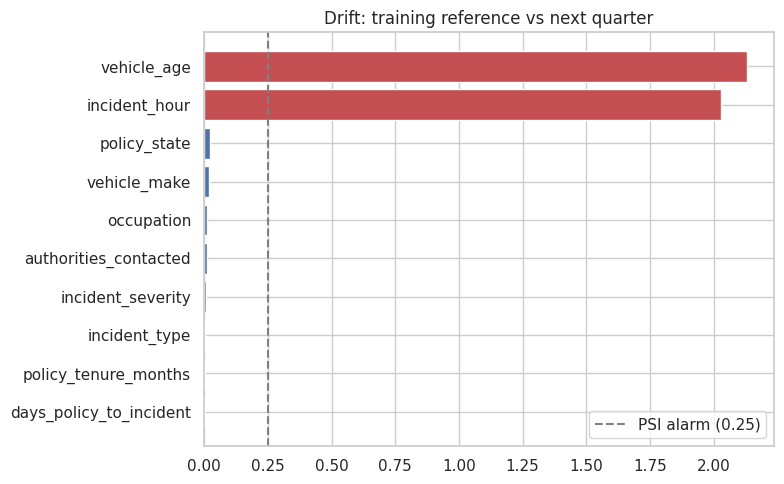

In [27]:
def psi(expected, actual, bins=10):
    expected, actual = expected.dropna(), actual.dropna()
    if expected.empty or actual.empty:
        return float("nan")
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    e = np.histogram(expected, bins=edges)[0] / len(expected)
    a = np.histogram(actual, bins=edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


def categorical_shift(expected, actual):
    e = expected.value_counts(normalize=True)
    a = actual.value_counts(normalize=True)
    idx = e.index.union(a.index)
    return float(0.5 * np.abs(e.reindex(idx, fill_value=0) - a.reindex(idx, fill_value=0)).sum())


def drift_report(reference, current):
    rows = []
    for col in NUMERIC_COLS:
        if col in reference and col in current:
            v = psi(reference[col], current[col])
            rows.append({"feature": col, "metric": "PSI", "value": round(v, 4), "drifted": v > 0.25})
    for col in CATEGORICAL_COLS:
        if col in reference and col in current:
            v = categorical_shift(reference[col], current[col])
            rows.append({"feature": col, "metric": "TVD", "value": round(v, 4), "drifted": v > 0.15})
    return pd.DataFrame(rows).sort_values("value", ascending=False).reset_index(drop=True)


# Simulate the next quarter.
next_quarter = generate(5_000, seed=99)
next_quarter["incident_hour"] = np.clip(next_quarter["incident_hour"] + 4, 0, 23)
next_quarter["vehicle_age"] = next_quarter["vehicle_age"] + 3
next_quarter = add_domain_features(next_quarter)

report = drift_report(train, next_quarter)
drifted = report[report["drifted"]]
print(f"{len(drifted)} feature(s) drifted beyond threshold:")
print(drifted.to_string(index=False))

top = report.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["value"],
         color=["#c44e52" if d else "#4c72b0" for d in top["drifted"]])
plt.axvline(0.25, ls="--", c="grey", label="PSI alarm (0.25)")
plt.title("Drift: training reference vs next quarter")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Serving layer

The same scoring functions behind a FastAPI service. The cell below defines the
app and, if FastAPI is installed, exercises it in-process with `TestClient` — no
server needed inside the notebook.

To run it for real, save the cell as `api.py` and:

```bash
uvicorn api:app --reload      # docs at http://localhost:8000/docs
```

In [28]:
if find_spec("fastapi"):
    from typing import Optional

    from fastapi import FastAPI, HTTPException
    from fastapi.testclient import TestClient
    from pydantic import BaseModel, Field

    class Claim(BaseModel):
        claim_id: str
        customer_age: int = Field(..., ge=16, le=100)
        gender: str = "M"
        occupation: str = "Salaried"
        policy_state: str = "MH"
        policy_type: str = "Comprehensive"
        policy_tenure_months: int = Field(..., ge=0, le=600)
        annual_premium: float = Field(..., gt=0)
        deductible: float = 2500
        num_prior_claims: int = 0
        vehicle_make: str = "Maruti"
        vehicle_age: int = 0
        incident_type: str = "Collision"
        incident_severity: str = "Minor Damage"
        incident_hour: int = Field(..., ge=0, le=23)
        incident_weekday: int = 0
        authorities_contacted: Optional[str] = "Police"
        witnesses: Optional[int] = 1
        police_report_filed: int = 1
        days_policy_to_incident: int = 30
        claim_amount: Optional[float] = None

    app = FastAPI(title="ClaimSense API", version="0.1.0")

    @app.get("/health")
    def health():
        return {"status": "ok",
                "models_loaded": FRAUD_MODEL_PATH.exists() and SEVERITY_MODEL_PATH.exists()}

    @app.post("/predict/fraud")
    def predict_fraud_endpoint(claim: Claim):
        df = pd.DataFrame([claim.model_dump()])
        row = score_fraud(df).iloc[0]
        drivers = explain_claim(fraud_model, feature_frame(add_domain_features(df), "fraud"))
        return {**row.to_dict(), "top_drivers": drivers.to_dict("records")}

    @app.post("/score")
    def score_endpoint(claims: list[Claim]):
        if not claims:
            raise HTTPException(status_code=422, detail="empty batch")
        return score_all(pd.DataFrame([c.model_dump() for c in claims])).to_dict("records")

    # ---- exercise the API in-process ------------------------------------
    client = TestClient(app)
    payload = suspicious.iloc[0].to_dict()

    print("GET /health ->", client.get("/health").json())

    response = client.post("/predict/fraud", json=payload).json()
    print("\nPOST /predict/fraud ->")
    print(json.dumps({k: v for k, v in response.items() if k != "top_drivers"},
                     indent=2, default=str))
    print("top drivers:", [d["feature"] for d in response["top_drivers"][:3]])

    print("\nPOST /score ->")
    print(json.dumps(client.post("/score", json=[payload]).json(), indent=2, default=str))
else:
    print("FastAPI not installed - run: pip install fastapi uvicorn")
    print("The scoring functions in section 13 are the full serving logic.")

GET /health -> {'status': 'ok', 'models_loaded': True}

POST /predict/fraud ->
{
  "claim_id": "LIVE-001",
  "fraud_probability": 0.9564,
  "flagged": 1,
  "risk_band": "High",
  "threshold": 0.18
}
top drivers: ['claim_to_premium_ratio', 'policy_tenure_months', 'police_report_filed']

POST /score ->
[
  {
    "claim_id": "LIVE-001",
    "fraud_probability": 0.9564,
    "flagged": 1,
    "risk_band": "High",
    "threshold": 0.18,
    "predicted_amount": 631056.83,
    "recommended_action": "Route to Special Investigation Unit"
  }
]


## 16. Results summary

In [29]:
fraud_final = classification_metrics(y_te, fraud_prob, thr_cost)
severity_best = severity_board.iloc[0]
lr_row = leaderboard[leaderboard["model"] == "logistic_regression"].iloc[0]

summary = pd.DataFrame([
    ["Fraud - PR-AUC (gradient boosting)", f"{fraud_final['pr_auc']:.3f}"],
    ["Fraud - PR-AUC (logistic baseline)", f"{lr_row['pr_auc']:.3f}"],
    ["Fraud - 5-fold CV PR-AUC", f"{cv_scores.mean():.3f} +/- {cv_scores.std():.3f}"],
    ["Fraud - chosen threshold", f"{thr_cost:.2f}"],
    ["Fraud - recall / precision", f"{fraud_final['recall']:.1%} / {fraud_final['precision']:.1%}"],
    ["Fraud - net savings (test set)", f"{savings:,.0f}"],
    ["Severity - best model", severity_best["model"]],
    ["Severity - MAE", f"{severity_best['mae']:,.0f}"],
    ["Severity - R2", f"{severity_best['r2']:.3f}"],
    ["Backend", BACKEND],
], columns=["metric", "value"])

print(summary.to_string(index=False))

                            metric                          value
Fraud - PR-AUC (gradient boosting)                          0.461
Fraud - PR-AUC (logistic baseline)                          0.306
          Fraud - 5-fold CV PR-AUC                0.398 +/- 0.013
          Fraud - chosen threshold                           0.18
        Fraud - recall / precision                  96.4% / 16.9%
    Fraud - net savings (test set)                      2,168,500
             Severity - best model              gradient_boosting
                    Severity - MAE                         11,820
                     Severity - R2                          0.857
                           Backend sklearn-hist-gradient-boosting


---

## What this notebook demonstrates

**Machine learning** — gradient boosting, imbalanced classification, class weighting,
log-target regression, stratified cross-validation, honest baselines at every step

**Evaluation** — PR-AUC over accuracy, Brier calibration, MAE/RMSLE/MAPE,
cost-based threshold optimisation, fairness slicing

**Engineering** — sklearn `Pipeline` / `ColumnTransformer` (no leakage across folds),
task-aware feature selection with assertions, model factory with backend fallback,
persisted artefacts, FastAPI serving

**Domain** — claims lifecycle, fraud red flags, loss-cost modelling, straight-through
processing vs SIU routing, regulator-facing explainability

---

## Honest limitations

- **Synthetic data.** The absolute numbers are optimistic. The pipeline is the
  deliverable, not the score. Swap in the Kaggle datasets named in section 2.
- **No temporal split.** Real claims data needs a time-based split; fraud patterns
  evolve and a random split leaks the future into the past.
- **Probabilities are not calibrated.** Brier score is reported; isotonic or
  Platt calibration is the next step.
- **Low precision by design.** 97% recall at ~16% precision is correct *given this
  cost matrix*. Change the two constants in section 1 and the optimum moves.

## Next steps

1. Optuna hyper-parameter search with MLflow tracking
2. Probability calibration (`CalibratedClassifierCV`, isotonic)
3. NLP features from adjuster notes / FIR text
4. Scheduled retraining triggered by the drift monitor in section 14
5. Streamlit dashboard wrapping the section 13 functions